<h1> GlycoSHIELD tutorial: how to model the post-translational modifications on the protein of interest?
<h3> This tutorial will demonstrate how to use GlycoSHIELD to model glycans on protein surfaces and explore their functional implications

In [ ]:
%load_ext autoreload
%autoreload 2

Imports and helper functions first.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import ipywidgets as widgets
import MDAnalysis as mda
from MDAnalysis.coordinates.PDB import PDBWriter
import numpy as np
import nglview
import matplotlib.pyplot as plt

from IPython.display import display,HTML
from functools import reduce
import py3Dmol

from glycoshield.lib import glycoshield,glycotraj,glycosasa
from glycoshield.NGL import NGL

import requests
import tempfile
import os

In [ ]:
def process_glycosylation_data(uniprot):
    """
    Fetches glycosylation data from a Uniprot page and generates data strings based on a template.
    
    Args:
        uniprot (str): The Uniprot ID to fetch data for.
        
    Returns:
        str: A string containing lines of data for each glycosylation site found, with each line
             generated based on the template "A XXX,YYY,ZZZ 1,2,3 GLYCAN_LIBRARY/Man5.pdb
             GLYCAN_LIBRARY/Man5_dt1000.xtc A_YYY.pdb A_YYY.xtc". 'XXX', 'YYY', and 'ZZZ' in
             the template are replaced with (glycosylation site - 1), glycosylation site, and
             (glycosylation site + 1), respectively.
    """    
    
    url = f"https://www.uniprot.org/uniprot/{uniprot}.txt"

    response = requests.get(url)
    lines = response.text.split('\n')

    glycosylation_data = []
    for line in lines:
        if 'CARBOHYD' in line:
            glycosylation_data.append(int(line.split()[2]))

    output = ''
    source_data = "A XXX,YYY,ZZZ 1,2,3 LIB_PATH/gs.27.M.Man9/reference.pdb LIB_PATH/gs.27.M.Man9/conformations.xtc WORK_PATH/A_YYY.pdb WORK_PATH/A_YYY.xtc"
    for line in glycosylation_data:
        xxx = line - 1
        zzz = line + 1
        modified = source_data.replace('YYY', str(line)).replace('XXX', str(xxx)).replace('ZZZ', str(zzz))
        output += modified + '\n'

    return output

def get_glycosylation_data(uniprot):
    """
    Fetches glycosylation data from a Uniprot page.
    
    Args:
        uniprot (str): The Uniprot ID to fetch data for.
        
    Returns:
        str: A list of residues to be glycosylated (int).
    """    
    
    url = f"https://www.uniprot.org/uniprot/{uniprot}.txt"

    response = requests.get(url)
    lines = response.text.split('\n')

    glycosylation_data = []
    for line in lines:
        if 'CARBOHYD ' in line:
            glycosylation_data.append(int(line.split()[2]))
    return glycosylation_data

def generate_input(glycosylation_data):
    """
    Generates input file based on provided list of residues.
    
    Args: A list of residues to be glycosylated (int).
    
    Returns: string containing lines of data for each glycosylation site found.
    """
    
    output = ''
    source_data = "A XXX,YYY,ZZZ 1,2,3 LIB_PATH/gs.27.M.Man9/reference.pdb LIB_PATH/gs.27.M.Man9/conformations.xtc WORK_PATH/A_YYY.pdb WORK_PATH/A_YYY.xtc"
    for line in glycosylation_data:
        xxx = line - 1
        zzz = line + 1
        modified = source_data.replace('YYY', str(line)).replace('XXX', str(xxx)).replace('ZZZ', str(zzz))
        output += modified + '\n'

    return output
    
def download_file(url, local_filename):
    """Downloads a file from a URL to a local path."""    
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    return local_filename
    
def create_folder_if_not_exists(folder_path):
    """helper function"""
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

def visualize_brushes(u_or_gs, mode="animate", frames=10, membrane=None):
    """
    Visualize glycan conformers using py3Dmol.
    
    mode="animate": animated trajectory of a single glycosylation site (pass MDAnalysis Universe)
    mode="static": static overlay of all sites simultaneously with color gradient (pass gs object)
    membrane: optional Z position of the membrane plane (draws an orange disk representation)
    """
    import py3Dmol
    import tempfile
    from MDAnalysis.coordinates.PDB import PDBWriter
    import MDAnalysis as mda
    import os

    if mode == "animate":
        u = u_or_gs
        protein = u.select_atoms("protein")
        glyc = u.select_atoms("not protein")

        frames_range = range(min(frames, len(u.trajectory)))

        with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
            tmp_path = tmp.name

        with PDBWriter(tmp_path, multiframe=True) as W:
            for i in frames_range:
                u.trajectory[i]
                W.write(protein + glyc)

        with open(tmp_path, "r") as f:
            pdb_data = f.read()
        os.unlink(tmp_path)

        view = py3Dmol.view(width=900, height=650)
        view.addModelsAsFrames(pdb_data, "pdb")
        view.setStyle({"protein": True}, {"cartoon": {"color": "lightgray"}})
        view.setStyle({"protein": False}, {"stick": {"color": "green", "radius": 0.2}})
        view.zoomTo()
        view.animate({"loop": "forward"})
        view.setBackgroundColor("white")
        view.render()
        view.show()
        
    elif mode == "static":
        # Pattern from glycoshield.app.visPy3Dmol.visualize_brushes:
        # Each glycan frame written as individual PDB, loaded via addModel + getModel().setStyle()
        gs = u_or_gs
        n_sites = len(gs.pdblist)
        
        startsugarcolor = "#009392"
        endsugarcolor = "#d0587e"
        
        def hex_to_RGB(h):
            return [int(h[i:i+2], 16) for i in range(1, 6, 2)]
        def RGB_to_hex(RGB):
            RGB = [int(x) for x in RGB]
            return "#" + "".join(["0{0:x}".format(v) if v < 16 else "{0:x}".format(v) for v in RGB])
        
        s = hex_to_RGB(startsugarcolor)
        f = hex_to_RGB(endsugarcolor)
        site_colors = [RGB_to_hex(s)]
        for t in range(1, n_sites):
            curr = [int(s[j] + (float(t) / (n_sites - 1)) * (f[j] - s[j])) for j in range(3)]
            site_colors.append(RGB_to_hex(curr))
        
        view = py3Dmol.view(width=900, height=650)
        view.removeAllModels()
        
        # Load protein directly from gs.protpdb instead of the first sugar PDB
        u_prot = mda.Universe(gs.protpdb)
        protein = u_prot.select_atoms("protein")
        with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp_prot:
            prot_path = tmp_prot.name
        protein.write(prot_path)
        with open(prot_path, "r") as fh:
            prot_pdb = fh.read()
        os.unlink(prot_path)
        
        view.addModel(prot_pdb, "pdb")
        Prot = view.getModel()
        Prot.setStyle({"cartoon": {"arrows": True, "tubes": True, "style": "oval", "color": "white"}})
        
        # For each site, write individual PDB frames for glycan-only atoms
        for idx in range(n_sites):
            pdb_file = gs.pdblist[idx]
            xtc_file = gs.xtclist[idx]
            
            # Check if file exists and has size > 0 (to handle 0 occupancy sites)
            if not (os.path.exists(pdb_file) and os.path.exists(xtc_file) and os.path.getsize(pdb_file) > 0):
                print(f"Skipping visualization for site at index {idx} ({pdb_file}) - no conformers were accepted.")
                continue
                
            u_site = mda.Universe(pdb_file, xtc_file)
            glyc = u_site.select_atoms("not protein")
            actual_frames = min(frames, len(u_site.trajectory))
            
            for i in range(actual_frames):
                u_site.trajectory[i]
                with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp_sugar:
                    sugar_path = tmp_sugar.name
                glyc.write(sugar_path)
                with open(sugar_path, "r") as fh:
                    sugar_pdb = fh.read()
                os.unlink(sugar_path)
                
                view.addModel(sugar_pdb, "pdb")
                zzz = view.getModel()
                zzz.setStyle({}, {"stick": {"color": site_colors[idx], "radius": 0.15, "opacity": 1.0}})
        
        view.zoomTo()
        
        if membrane is not None:
            view.addCylinder({
                "start": {"x": 0.0, "y": 0.0, "z": float(membrane) - 0.2},
                "end": {"x": 0.0, "y": 0.0, "z": float(membrane) + 0.2},
                "radius": 120.0,
                "color": "orange",
                "opacity": 0.4
            })
            
        view.setBackgroundColor("white")
        view.show()

Let's start with setting the environment and define functions to fetch data from the __[AlphaFold Protein Structure Database](https://alphafold.ebi.ac.uk/)__ and PTM section of __[UniProt website](https://www.uniprot.org/)__.

AlphaFold Protein Structure Database consists of predicted protein structure models obtained by AlphaFold software - state-of-the-art AI system of Google DeepMind (__[link to the paper](https://www.nature.com/articles/s41586-021-03819-2)__). It's curated in partnership with __[EMBL's European Bioinformatics Institute (EMBL-EBI)](https://www.ebi.ac.uk/)__ and currently consists of around 200 million models, providing broad coverage of UniProt (the standard repository of protein sequences and annotations). The database provides individual downloads for the human proteome and for the proteomes of 47 other key organisms important in research and global health, as well as a download for the manually curated subset of UniProt (Swiss-Prot).

<h2> Preparing the setup

In this tutorial we will use the structure of human __Neural cell adhesion molecule 1__ (AF3 db id AF-Q9BY67-5-F1-v6).

Go to the AlphaFold Protein Structure Database and search for this protein.
Then provide the UniProt ID in the cell below (the highlighted part)

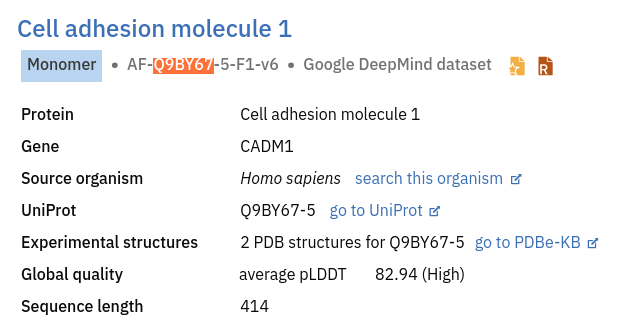

In [ ]:
#uniprot='Q9BY67'
uniprot='Q9BY67'


While you're already there, click on the selected entry and explore the entry page __[here](https://alphafold.ebi.ac.uk/entry/AF-Q9BY67-5-F1)__.

Take a look at the structure and play with it a bit - you're going to decorate it with glycans in a minute!

The following code will download the model from the AlphaFold Protein Structure Database

In [ ]:
path="./tmp_files/"
create_folder_if_not_exists(path)
pdbfile="https://alphafold.ebi.ac.uk/files/AF-{}-5-F1-model_v6.pdb".format(uniprot)
infile="AF-{}-5-F1-model_v6.pdb".format(uniprot)
inputname=path+'input_sugaring_{}'.format(uniprot)
try:
    download_file(pdbfile,infile)
except:
    raise BaseException("AlphaFold entry does not exist or pdb file not found! Exiting...")

Now the code will get the glycosylation sites from UniProt PTM section and prepare the input for GlycoSHIELD run<br> 
Please have a look on the printed output below <br>
You will see that the software is adding Man9 glycan in several different regions of the protein <br>

GlycoSHIELD contains a comprehensive database of multiple well-sampled glycans trajectories. 

Here, we will use only Man9, but feel free to explore the database at __[GlycoSHIELD Glycan Conformers Library on Zenodo](https://zenodo.org/records/6983057)__.

In [ ]:
glycosites = get_glycosylation_data(uniprot)
result = generate_input(glycosites)

#lib_path="/net/software/trainings/2026/2026-06-30-mcb-eebg/glycoshield-md/GLYCAN_LIBRARY/"
lib_path="./glycoshield-md/GLYCAN_LIBRARY/"
result=result.replace("WORK_PATH/",path).replace("LIB_PATH/",lib_path)
# write result to file
with open(inputname, 'w') as f:
    f.write(result)
print(result)

## Running GlycoSHIELD

GlycoSHIELD grafts glycan conformers onto the protein structure. Here is what happens step by step:

1. **Input parsing**: The input file specifies each glycosylation site — chain, residue IDs, and the glycan conformer library (PDB reference + XTC trajectory of pre-sampled conformers).
2. **Alignment**: For each conformer in the library, the glycan's peptide backbone is superimposed onto the protein's target residue using least-squares fitting.
3. **Clash rejection**: After alignment, steric clashes between the glycan and the protein are detected. If any glycan atom is closer than the `threshold` (default 3.5 Å) to a protein Cα atom, the conformer is rejected.
4. **Membrane boundary** (optional): The `zmin` / `zmax` parameters define spatial boundaries (e.g., a membrane plane). Any glycan conformer with atoms crossing the boundary is also rejected.
5. **Output**: For each site, the accepted conformers are saved as a PDB + XTC trajectory.

The key output is the **occupancy** — how many conformers (out of the full library) were accepted at each site. Higher occupancy = more conformationally accessible site.

In [ ]:
gs = glycoshield(protpdb=infile,protxtc=None,inputfile=inputname,path=path,skip=10)

Now we run the grafting. The `occupancy_single` array reports how many conformers were successfully grafted at each glycosylation site.

Higher occupancy means the site is more sterically accessible.

In [ ]:
occupancy_single = gs.run()
print(occupancy_single)

### Accepted Conformer Counts per Site (No Membrane)

In [ ]:
# Plot occupancies of the glycosites after first grafting
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(gs.reslist))
ax.bar(x, occupancy_single[0], color='#009392', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Glycosylation site (residue)', fontsize=12)
ax.set_ylabel('Accepted conformers', fontsize=12)
ax.set_title('Glycan Conformer Acceptance per Site (No Membrane)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in gs.reslist], fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 1. Animated Single-Site Conformation Dynamics

To understand how glycans move and sample conformational space, we can visualize the generated trajectory for a single glycosylation site. The animation below shows sequential conformers grafted onto a single site, illustrating the dynamic nature of the glycan brush.

In [ ]:
# Select one of the generated glycosylated states dynamically
pdb_file = gs.pdblist[4] if len(gs.pdblist) > 4 else gs.pdblist[0]
xtc_file = gs.xtclist[4] if len(gs.xtclist) > 4 else gs.xtclist[0]
u = mda.Universe(pdb_file, xtc_file)

visualize_brushes(u, mode="animate", frames=10)

### 2. Static Multi-Site Glycan Brush ("Shield") View

While animation helps understand dynamics at a single site, the biological function of glycans — the **"shielding" effect** — is best visualized by looking at all grafting sites simultaneously.

The visualization below overlays multiple conformers for **all** glycosylation sites at once:
- **Protein backbone**: white cartoon
- **Glycan conformers**: each site has a unique color from a teal-to-rose gradient
  - **Teal** (#009392): first glycosylation site
  - **Rose** (#d0587e): last glycosylation site
  - Intermediate sites are colored along this gradient

This collective "brush" of glycans creates a protective steric envelope around the protein surface, shielding it from molecular interactions.

In [ ]:
visualize_brushes(gs, mode="static", frames=10)

## Quantifying the Glycan Shield: ∆SASA Analysis

To measure how much the glycans protect each part of the protein surface, we compute the **Solvent-Accessible Surface Area (SASA)**.

SASA measures how much of a protein residue's surface is accessible to a solvent probe (typically water, with probe radius $r = 1.4$ Å) using the **Shrake-Rupley algorithm**.

We calculate:
1. **Bare SASA** ($\text{SASA}_i^{\text{bare}}$): surface area of residue $i$ on the protein alone (no glycans)
2. **Glycosylated SASA** ($\text{SASA}_i^{\text{glyc}}$): surface area of the same residue with glycans present

The **relative shielding** is then:

$$\Delta\text{SASA}_i = 1 - \frac{\text{SASA}_i^{\text{glyc}}}{\text{SASA}_i^{\text{bare}}}$$

| $\Delta\text{SASA}_i$ | Interpretation |
|---|---|
| 0 | No shielding — residue is equally accessible with or without glycans |
| 1 | Fully shielded — glycans completely block solvent access |
| Intermediate | Partial shielding |

This analysis requires **GROMACS** in the system path (for the `gmx sasa` command).

In [ ]:
myprobe=0.14 # Probe radius

from glycoshield.lib import glycoshield,glycotraj,glycosasa

maxframe=np.min(occupancy_single[0]) 
maxframe=3 # temporary reduction of the no of frames to speed things up
pdblist=gs.pdblist
xtclist=gs.xtclist
chainlist=gs.chainlist
probelist=[myprobe]
plottrace=True
ndots=5 # reduced sasa resolution for speed
mode="max"
keepoutput=False

sasas = glycosasa(pdblist=pdblist,xtclist=xtclist,plottrace=plottrace,
          probelist=probelist,ndots=ndots,mode=mode,keepoutput=keepoutput,maxframe=maxframe,
          path=path,chainlist=chainlist)

Visualise the shielding as a surface colored by ∆SASA (orange/red = shielded, gray = unshielded):

In [ ]:
from glycoshield.NGL import NGLSASA

occupancy=sasas[0][5] # hard-coded, remember to change if using many probe radii.
residues=sasas[0][0]
sasavis=NGLSASA(path=path,pdbfile='maxResidueSASA_probe_{}.pdb'.format(myprobe),occupancy=occupancy,residues=residues)
v1=sasavis.build_representation()
v1

## Effect of a Membrane Boundary on Glycan Grafting

CADM1 (Neural cell adhesion molecule 1) is a **transmembrane protein**. Its transmembrane helix spans approximately residues **346–374**, anchoring the ectodomain to the lipid bilayer.

To model the membrane's steric effect on glycan conformers, we will:
1. **Orient the protein** so that the TM helix is aligned along the Z axis (res 346 pointing toward +Z)
2. **Translate** so that residue 346 Cα sits at $z = 0$, representing the membrane surface
3. **Re-run GlycoSHIELD** with `zmin=0.0` — any glycan conformer dipping below $z = 0$ (into the membrane) will be rejected

This allows us to compare glycan occupancies **with and without** the membrane boundary.

In [ ]:
from scipy.spatial.transform import Rotation

# Load the protein structure
u_orient = mda.Universe(infile)

# Select TM helix CA atoms
tm_ca = u_orient.select_atoms("resid 346:374 and name CA")

# Compute helix axis: vector from res374 → res346 (346 should point to +Z)
p_346 = u_orient.select_atoms("resid 346 and name CA").positions[0]
p_374 = u_orient.select_atoms("resid 374 and name CA").positions[0]

helix_vec = p_346 - p_374
helix_vec = helix_vec / np.linalg.norm(helix_vec)

# Target: Z axis
z_axis = np.array([0.0, 0.0, 1.0])

# Rotation axis = cross product, angle = arccos(dot product)
rot_axis = np.cross(helix_vec, z_axis)
rot_axis_norm = np.linalg.norm(rot_axis)

if rot_axis_norm > 1e-8:
    rot_axis = rot_axis / rot_axis_norm
    angle = np.arccos(np.clip(np.dot(helix_vec, z_axis), -1, 1))
    rotation = Rotation.from_rotvec(angle * rot_axis)
    
    # Apply rotation to all atoms
    com = u_orient.atoms.center_of_mass()
    u_orient.atoms.positions -= com
    u_orient.atoms.positions = rotation.apply(u_orient.atoms.positions)

# Translate so that res 346 CA is at z=0
p_346_new = u_orient.select_atoms("resid 346 and name CA").positions[0]
u_orient.atoms.positions[:, 2] -= p_346_new[2]

# Save the oriented structure
oriented_pdb = "AF-{}-5-F1-model_v6_oriented.pdb".format(uniprot)
u_orient.atoms.write(oriented_pdb)

# Verify
p_346_check = u_orient.select_atoms("resid 346 and name CA").positions[0]
p_374_check = u_orient.select_atoms("resid 374 and name CA").positions[0]
print(f"Res 346 CA position: {p_346_check} (z should be ~0)")
print(f"Res 374 CA position: {p_374_check} (z should be negative)")
print(f"Helix direction check: 346 z > 374 z? {p_346_check[2] > p_374_check[2]}")

### Re-run GlycoSHIELD with membrane boundary

Now we re-run the grafting on the oriented structure with `zmin=0.0`. The input file needs to be regenerated to use the oriented PDB.

We set `dryrun=False` (enabling visual generation of conformers in the output directory) and `ignorewarn=True` to continue even if some sites have zero accepted conformers.

In [ ]:
# Create output directory for membrane run
path_membrane = "./tmp_files_membrane/"
create_folder_if_not_exists(path_membrane)

# Regenerate input file for membrane run
inputname_membrane = path_membrane + 'input_sugaring_{}_membrane'.format(uniprot)
result_membrane = generate_input(glycosites)
result_membrane = result_membrane.replace("WORK_PATH/", path_membrane).replace("LIB_PATH/", lib_path)
with open(inputname_membrane, 'w') as f:
    f.write(result_membrane)

gs_membrane = glycoshield(protpdb=oriented_pdb,
                          protxtc=None,
                          inputfile=inputname_membrane,
                          path=path_membrane,
                          skip=10,
                          zmin=0.0,
                          dryrun=False,
                          ignorewarn=True)

occupancy_membrane = gs_membrane.run()
print("Occupancy with membrane boundary:")
print(occupancy_membrane)

### Visualizing the Membrane-Oriented Glycan Brush

In [ ]:
# Visualize the oriented membrane-bound glycan brush with a plane at z=0.0 representing the membrane surface
visualize_brushes(gs_membrane, mode="static", frames=10, membrane=0.0)

### Comparison: Glycan Occupancies With and Without Membrane

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(gs.reslist))
width = 0.35

bars1 = ax.bar(x - width/2, occupancy_single[0], width, 
               label='No membrane', color='#009392', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, occupancy_membrane[0], width, 
               label='With membrane (zmin=0)', color='#d0587e', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Glycosylation site (residue)', fontsize=12)
ax.set_ylabel('Accepted conformers', fontsize=12)
ax.set_title('Effect of Membrane Boundary on Glycan Conformer Acceptance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in gs.reslist], fontsize=11)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Discussion

**Question**: Compare the occupancies with and without the membrane boundary.

1. Which glycosylation sites are most affected by the presence of the membrane?
2. Sites closer to the TM helix (membrane-proximal) should lose more conformers. Why?
3. What does this suggest about the **preferred orientation** of the ectodomain relative to the membrane?

> **Entropic repositioning hypothesis**: When glycans at membrane-proximal sites lose many conformers due to clashes with the membrane surface, this represents an **entropic cost** ($\Delta S < 0$). 
> The protein can minimize this cost by adopting a more **upright orientation**, where the glycan brush extends away from the membrane. 
> This entropic effect may contribute to the preferred tilt angle of cell adhesion molecules at the cell surface, effectively making the protein stand more upright to avoid glycan-membrane clashes.

Think about what other biological implications this might have for cell-cell adhesion and signal transduction.